# Bilevel Policy Design with Regulated Multi-Agent Systems
## A Step-by-Step Guide Using the Fishery Case Study

This notebook explains how to design **institutional policies** using a **bilevel optimization framework**, 
where an outer decision-maker (regulator) optimizes policy parameters, 
and inner agents adapt optimally via reinforcement learning.

We proceed **from theory → abstractions → concrete code**, using the fishery environment as a running example.

-----------

In [ ]:
from dataclasses import dataclass

import numpy as np
from numpy.typing import NDArray

from core.annotations import override

### Problem Class: Bilevel Policy Design


We consider a **bilevel optimization problem**:

- An **institution (Leader)** selects a *policy mechanism*  
- A population of **agents (Followers)** adapts optimally to this mechanism  
- The institution evaluates long-term outcomes and updates the policy

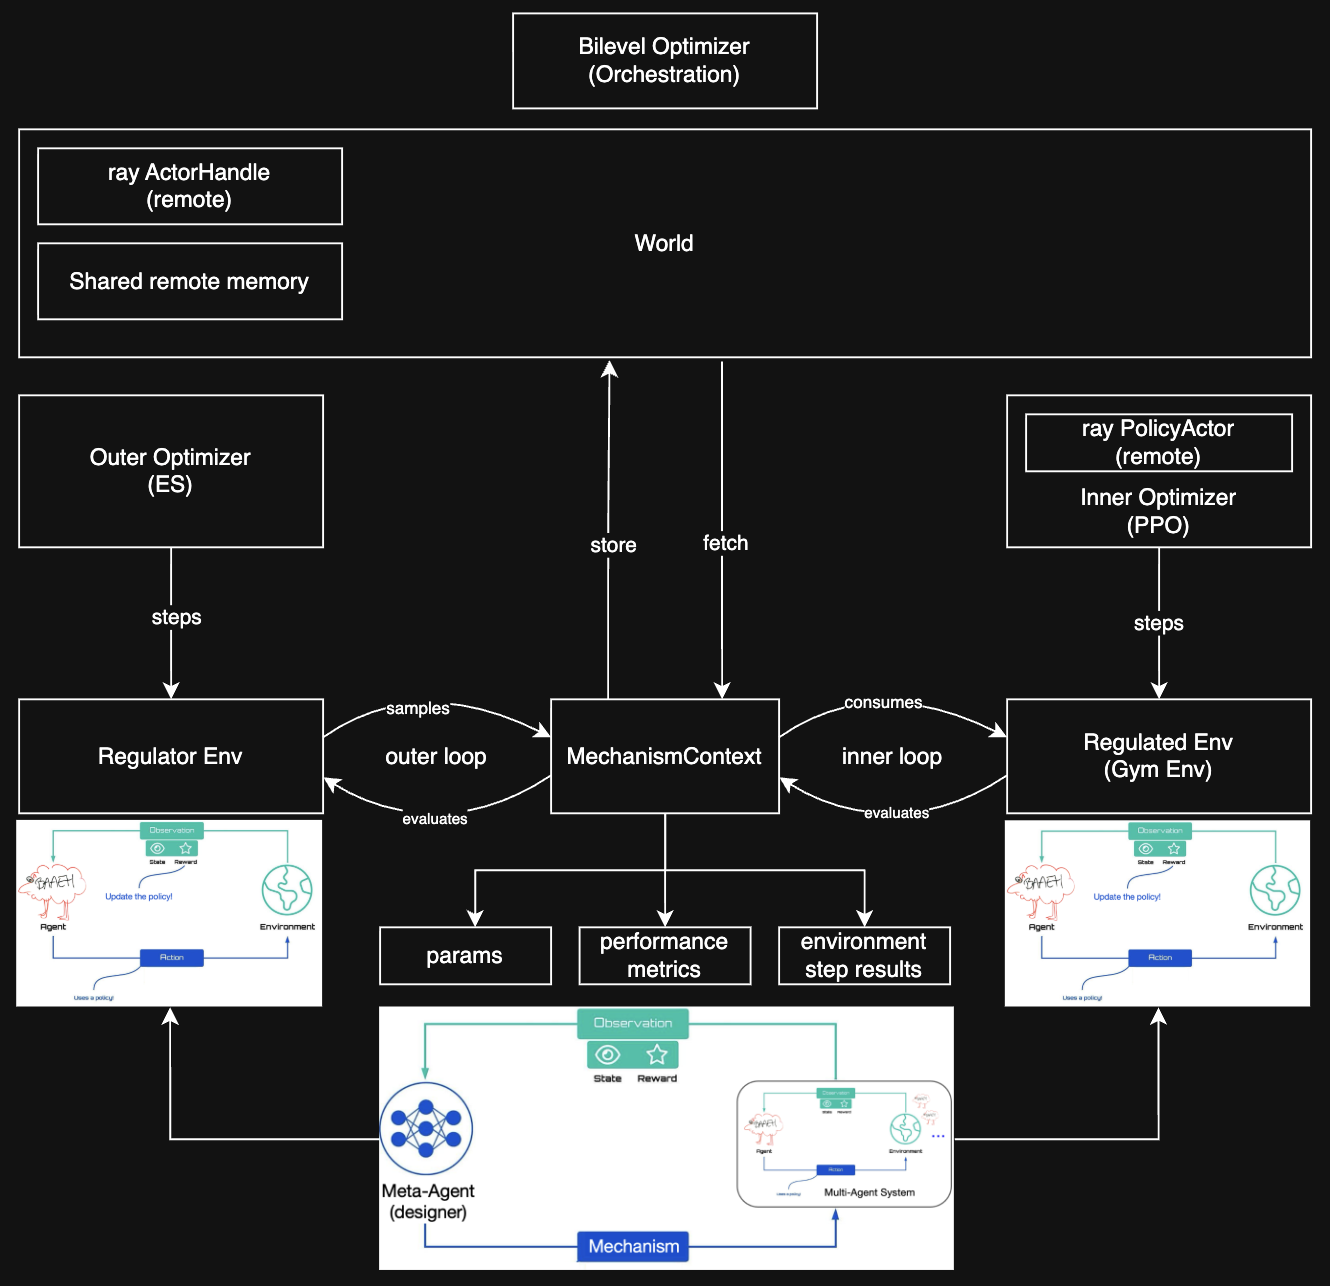

### Canonical Bilevel Optimization - Abstract Formulation

$$
\Theta^* \in \arg\max_{\theta \in \Theta} J_{\mathrm{outer}}(\theta)
$$

subject to:

$$
\phi^*(\theta) \in \arg\max_{\phi \in \Phi} J_{\mathrm{inner}}(\phi; \theta)
$$

Where:

- $ \theta $: institutional policy parameters  
- $ \phi $: agent policy parameters  
- $ J_{\mathrm{inner}} $: agent return under policy $ \theta $  
- $ J_{\mathrm{outer}} $: institutional objective over induced behavior  

The inner problem is typically an **MDP**; the outer problem is often **non-differentiable**.


### Mapping Theory to the Fishery Domain

| Concept | Canonical | Fishery |
|------|---------|--------|
| Leader | Institutional optimizer | Fishery regulator |
| Followers | Agents | Fishermen |
| Policy variable | $ \theta $ | $ \mu = \{fq, pq, ms, fa, bp\} $ |
| State | $ S $ | $ S = \{A, F\} $ (algae, fish) |
| Action | $ a $ | Harvest fraction |
| Dynamics | $ T $ | Lotka–Volterra + harvest |
| Agent utility | $ u(s,a) $ | $ a_t^{(i)} F_t $ |
| Violation | $ g_\theta(s,a) $ | quota + ban |
| Penalty | $ \phi_\theta(g) $ | fine × violation |
| Optimizers | ES / PPO | ES (outer), PPO (inner) |

Every row of the table maps to a concrete class.

###  Mechanism: What Is the Institution Allowed to Decide?

A **Mechanism** is the *entire institutional rulebook* exposed to agents.

In fishery:

$$
\mu = \{ fq,\; pq,\; ms,\; fa,\; bp \}
$$

- Fixed quota
- Proportional quota
- Minimum stock threshold
- Fine amount
- Ban duration

### Design principle

A mechanism:
1. Must be **compact**
2. Must be **interpretable**
3. Must **parameterize all institutional power**


In [3]:
from core.mechanism.base import Mechanism


@dataclass(frozen=True)
class FisheryMechanism(Mechanism):
    """
    Institutional policy for the fishery domain.

    Conceptual role:
        Represents the regulator’s decision variable μ (outer-loop action).

    Why this is required:
        The outer optimizer (ES) needs a *compact, interpretable* policy object
        that can be:
          - logged and compared
          - injected into the regulated environment
          - encoded/decoded to a bounded optimization vector

    Parameters (μ):
        fixed_quota (fq): absolute harvest cap
        prop_quota (pq): harvest cap proportional to current stock
        min_stock (ms): minimum stock below which fishing is banned
        fine_amount (fa): penalty multiplier per unit violation
        ban_period (bp): discrete ban duration after violation
    """

    fixed_quota: float
    prop_quota: float
    min_stock: float
    fine_amount: float
    ban_period: int

    def __post_init__(self) -> None:
        """
        Validate domain constraints.

        Why this matters:
            - Prevents invalid institutional policies from entering training
            - Keeps optimization stable by enforcing feasible policy space
        """
        assert 0.0 <= self.fixed_quota <= 1.0
        assert 0.0 <= self.prop_quota <= 1.0
        assert 0.0 <= self.min_stock <= 1.0
        assert 0.0 <= self.fine_amount <= 2.0
        assert 0 <= self.ban_period <= 10

    @override(Mechanism)
    def to_vector(self) -> np.ndarray:
        """
        Encode μ into a normalized vector in [0,1]^d.

        Conceptual role:
            Provides a canonical representation used by:
              - logging/serialization
              - distance-based diagnostics
              - mechanism-space encoding

        Note:
            Discrete and scaled parameters must be normalized consistently.
        """
        return np.array(
            [
                self.fixed_quota,
                self.prop_quota,
                self.min_stock,
                self.fine_amount / 2.0,   # map [0,2] -> [0,1]
                self.ban_period / 10.0,   # map {0..10} -> [0,1]
            ],
            dtype=np.float32,
        )

    # TODO move this to base class. they dont need to worry about serialization and deserialization
    def param_names(self) -> list[str]:
        """
        Human-readable parameter names in vector order.

        Why this matters:
            Enables generic tooling (plots, tables, logging)
            without hardcoding domain-specific labels.
        """
        return ["fixed_quota", "prop_quota", "min_stock", "fine_amount", "ban_period"]


    
    # TODO function to get stored params

In [7]:
# Create a single institutional policy
mu = FisheryMechanism(
    fixed_quota=0.25,
    prop_quota=0.15,
    min_stock=0.2,
    fine_amount=1.2,
    ban_period=3,
)

# Inspect its semantic parameters
print("Mechanism parameters:")
for name, val in zip(mu.param_names(), mu.to_vector()):
    print(f"{name:>12}: {val:.3f}")

# retreive mechanism param names
mu.param_names


# This vector is what the outer optimizer actually manipulates
mu.to_vector()

Mechanism parameters:
 fixed_quota: 0.250
  prop_quota: 0.150
   min_stock: 0.200
 fine_amount: 0.600
  ban_period: 0.300


array([0.25, 0.15, 0.2 , 0.6 , 0.3 ], dtype=float32)

### Mechanism Space: How Do We Optimize Policies?

The outer optimizer (ES) does **not** operate on raw parameters.

Instead, we define:
$$
\Theta = [0,1]^d
$$

Then map:
$$
u \in [0,1]^d \rightarrow \mu \in \text{Mechanism}
$$

Why?

- Enables black-box optimization
- Guarantees bounds
- Allows discrete components (e.g. ban length)


In [ ]:

from core.mechanism.space import MechanismSpace


class FisheryMechanismSpace(MechanismSpace):
    """
    MechanismSpace for the fishery domain.
AC
    Conceptual role:
        Defines the mapping between:
          - optimizer coordinates u ∈ [0,1]^d
          - interpretable mechanism objects μ

    Why this is required:
        The outer optimizer operates on vectors.
        The environment operates on a Mechanism object.
        This class is the bridge between the two.

    Design requirements:
        - enforce bounds (clip)
        - support discrete parameters (ban_period)
        - ensure deterministic or controlled stochastic rounding
    """

    def __init__(self, use_stochastic_rounding: bool = True):
        """
        Args:
            use_stochastic_rounding:
                If True, discretize ban_period using stochastic rounding
                to reduce bias when ES explores near integer boundaries.
        """
        super().__init__()
        self.use_stochastic_rounding = use_stochastic_rounding
        self.dimension = 5

    def _denormalize(self, u: NDArray[np.float32]) -> dict:
        """
        Convert u ∈ [0,1]^d into raw parameter values.

        Why this matters:
            Many domains have mixed ranges:
            - some parameters naturally live in [0,1]
            - others require scaling (fine amount, durations, taxes, etc.)
        """
        return {
            "fixed_quota": float(u[0]),
            "prop_quota": float(u[1]),
            "min_stock": float(u[2]),
            "fine_amount": float(u[3]) * 2.0,       # [0,1] -> [0,2]
            "ban_period_cont": float(u[4]) * 10.0,  # [0,1] -> [0,10]
        }

    def _discretize_ban(self, ban_period_cont: float, u: NDArray[np.float32]) -> int:
        """
        Discretize the continuous ban parameter into an integer.

        Why this matters:
            The policy includes a *discrete institutional action*.
            ES proposes continuous values, so we need a controlled mapping.

        Stochastic rounding:
            Interprets ban_period_cont = k + α as:
              ban = k with prob (1-α), ban = k+1 with prob α
            using a deterministic pseudo-random seed derived from u.
        """
        if not self.use_stochastic_rounding:
            return int(np.clip(round(ban_period_cont), 0, 10))

        floor = int(np.floor(ban_period_cont))
        frac = float(ban_period_cont - floor)

        # deterministic pseudo-randomness based on u
        h = hash(tuple(map(float, u)))
        pseudo = (h % 10000) / 10000.0

        if pseudo < frac and floor < 10:
            return floor + 1
        return floor

    # TODO can be moved to base class
    def encode(self, m: FisheryMechanism) -> NDArray[np.float32]:
        """
        Convert a Mechanism object into optimizer coordinates u ∈ [0,1]^d.

        Why this matters:
            Enables:
              - warm starts from known good policies
              - logging policies in a canonical vector form
              - replaying policies across experiments
        """
        return m.to_vector()

    def decode(self, x: NDArray[np.float32]) -> FisheryMechanism:
        """
        Convert x into a valid FisheryMechanism.

        Contract:
            - x may be out of bounds
            - output must be a valid Mechanism instance

        Why this matters:
            Outer optimization often proposes invalid candidates.
            decode() is responsible for producing feasible policies.
        """
        u = np.clip(self._validate(x), 0.0, 1.0)
        params = self._denormalize(u)
        ban = self._discretize_ban(params.pop("ban_period_cont"), u)

        mech = FisheryMechanism(**params, ban_period=ban)
        return self.clip(mech)

    def clip(self, m: FisheryMechanism) -> FisheryMechanism:
        """
        Project an arbitrary mechanism back into the feasible set.

        Why this matters:
            Provides a final safety net so downstream code never
            receives invalid institutional policies.
        """
        return FisheryMechanism(
            fixed_quota=float(np.clip(m.fixed_quota, 0, 1)),
            prop_quota=float(np.clip(m.prop_quota, 0, 1)),
            min_stock=float(np.clip(m.min_stock, 0, 1)),
            fine_amount=float(np.clip(m.fine_amount, 0, 2)),
            ban_period=int(np.clip(m.ban_period, 0, 10)),
        )

    # TODO removed unused method since already in base class
    @classmethod
    def default(cls) -> FisheryMechanism:
        """
        Provide a reasonable baseline policy μ₀.

        Why this matters:
            Defaults are useful for:
              - smoke tests
              - sanity baselines
              - initializing ES mean around a plausible policy
        """
        return FisheryMechanism(
            fixed_quota=0.2,
            prop_quota=0.1,
            min_stock=0.1,
            fine_amount=1.0,
            ban_period=2,
        )


In [10]:
space = FisheryMechanismSpace()

# Sample optimizer coordinates
u = np.array([0.4, 0.1, 0.3, 0.7, 0.55], dtype=np.float32)

# Decode into an institutional policy
mu = space.decode(u)

print("Optimizer vector:", u)
print("Decoded mechanism:", mu)

# Encode back (round-trip safety)
space.encode(mu)

Optimizer vector: [0.4  0.1  0.3  0.7  0.55]
Decoded mechanism: FisheryMechanism(fixed_quota=0.4000000059604645, prop_quota=0.10000000149011612, min_stock=0.30000001192092896, fine_amount=1.399999976158142, ban_period=6)


array([0.4, 0.1, 0.3, 0.7, 0.6], dtype=float32)

### Inner Loop: Agent Decision Making

Agents solve:

$$
\Phi^*(\theta) = \arg\max_\phi \mathbb{E}_\pi \left[ 
\sum_{t=0}^H \sum_{i=1}^N 
\left(
u_t^{(i)} - \phi_\theta(g_t^{(i)})
\right)
\right]
$$

This is a **standard MDP**:
- State: fish & algae
- Action: harvest
- Reward: utility − penalty

### Regulated Environment

The regulated environment:
- Injects the **mechanism**
- Computes **violations**
- Applies **penalties**
- Leaves learning to PPO

This ensures:
- Institutional logic ≠ agent policy
- Clean separation of concerns

### Violation signal

$$
g_\theta(s,a) =
\max(0, u^{(i)} - \min(fq, pq \cdot F_t))
+ \mathbb{1}[F_t < ms] \cdot u^{(i)}
$$

### Penalty

$$
\phi_\theta(g) = fa \cdot g
$$

This exactly matches `violation_signal()` and `penalty()` in code.


In [12]:
from typing import SupportsFloat

from gymnasium.core import ActType

from ray.rllib.utils.typing import AgentID, MultiAgentDict
from core.envs.marl_regulated import MultiAgentRegulatedEnv


class FisheryRegulatedEnv(MultiAgentRegulatedEnv):
    """
    Multi-agent environment where agents operate under an institutional mechanism.

    Conceptual role:
        - Defines the *inner MDP* solved by agents
        - Encodes how institutional rules affect agent rewards
        - Does NOT define institutional objectives

    Why this class is required:
        Every new policy-design domain must specify:
        - State dynamics
        - Agent utility
        - How violations are computed
        - How penalties are applied
    """

    def __init__(self, *, ecology_cfg: dict, **kwargs):
        """
        Initialize the regulated environment.

        Args:
            ecology_cfg:
                Domain-specific parameters governing the latent system
                dynamics (e.g. Lotka–Volterra constants).
        """
        super().__init__(**kwargs)

        self.algae_init = ecology_cfg["algae_init"]
        self.fish_init = ecology_cfg["fish_init"]
        self.max_fish = ecology_cfg["max_fish"]
        self.max_algae = ecology_cfg["max_algae"]

        self.alpha = ecology_cfg["alpha"]
        self.beta = ecology_cfg["beta"]
        self.gamma = ecology_cfg["gamma"]
        self.delta = ecology_cfg["delta"]
        self.dt = ecology_cfg["dt"]

    
    def _reset(self):
        """
        Sample the initial latent system state.

        Conceptual role:
            Defines the initial state distribution p₀(s).

        Why it matters:
            Institutional evaluation assumes all mechanisms
            are tested under the *same stochastic initial conditions*.
        """
        self.S_t = {
            "fish": max(1e-8, self.rng.lognormal(np.log(self.fish_init), 0.05)),
            "algae": max(1e-8, self.rng.lognormal(np.log(self.algae_init), 0.05)),
        }

        return {
            agent_id: self.observation(agent_id, self.S_t)
            for agent_id in self.agents
        }
    
    def intrinsic_utility(
        self,
        agent_id: AgentID,
        action: ActType,
        S_t: dict[str, float],
    ) -> SupportsFloat:
        """
        Compute the agent's intrinsic (pre-regulation) utility.

        Conceptual role:
            Encodes the *private objective* of agents,
            independent of institutional constraints.

        Fishery interpretation:
            Agents prefer harvesting when fish stock is high.

        Returns:
            Scalar utility before penalties.
        """
        action = float(np.asarray(action).item())
        fish_norm = S_t["fish"] / self.max_fish
        return action * fish_norm
    
    def violation_signal(
        self,
        agent_id: AgentID,
        u_i: SupportsFloat,
        S_t: dict[str, float],
    ) -> SupportsFloat:
        """
        Compute institutional violations for an agent.

        Conceptual role:
            Defines g_θ(s, a), the rule-breaking signal
            controlled by the mechanism.

        Fishery interpretation:
            - Over-harvesting beyond quota
            - Harvesting when stock is below minimum threshold
        """
        quota_violation = max(
            0.0,
            u_i - min(self.m.fixed_quota, self.m.prop_quota * S_t["fish"]),
        )

        ban_violation = float(S_t["fish"] < self.m.min_stock) * u_i

        return float(quota_violation + ban_violation)
    
    def penalty(self) -> SupportsFloat:
        """
        Institutional penalty applied per unit violation.

        Conceptual role:
            Maps violations into economic or regulatory cost.

        Why it is separate:
            Allows penalty strength to be optimized *without*
            redefining the violation logic.
        """
        return self.m.fine_amount

    def transition_kernel(
        self,
        A_t: MultiAgentDict,
        S_t: dict[str, float],
    ) -> dict[str, float]:
        """
        Latent system dynamics.

        Conceptual role:
            Defines the shared state evolution T(s, a).

        Fishery interpretation:
            Lotka–Volterra predator-prey dynamics
            with harvesting pressure.
        """
        fish = S_t["fish"]
        algae = S_t["algae"]

        desired = {
            agent_id: self.intrinsic_utility(agent_id, A_t[agent_id], S_t)
            for agent_id in self.agents
        }

        total_desired = sum(desired.values())
        scale = min(1.0, fish / max(1e-8, total_desired))

        harvest = self.max_fish * sum(
            desired[a] * scale for a in self.agents
        )

        fish_next = fish + self.dt * (
            self.delta * algae * fish
            - self.gamma * fish
            - harvest
        )

        algae_next = algae + self.dt * (
            self.alpha * algae
            - self.beta * algae * fish
        )

        return {
            "fish": float(np.clip(fish_next, 0.0, self.max_fish)),
            "algae": float(np.clip(algae_next, 0.0, self.max_algae)),
        }
    
    # TODO explain why it is aggregated for agents --> we are doing a shared policy
    @override(MultiAgentRegulatedEnv)
    def aggregate_rewards(
        self,
        rewards: MultiAgentDict,
    ) -> MultiAgentDict:
        """
        Aggregate agent rewards for learning.

        Conceptual role:
            Defines what PPO actually optimizes.

        Important:
            This is *not* the institutional objective.
            It is the agents' learning signal.
        """
        mean_reward = float(np.mean(list(rewards.values())))
        scaled = float(np.clip(50.0 * mean_reward, -10.0, 10.0))
        return {agent_id: scaled for agent_id in self.agents}



2026-02-02 07:30:52,484	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-02 07:30:59,346	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


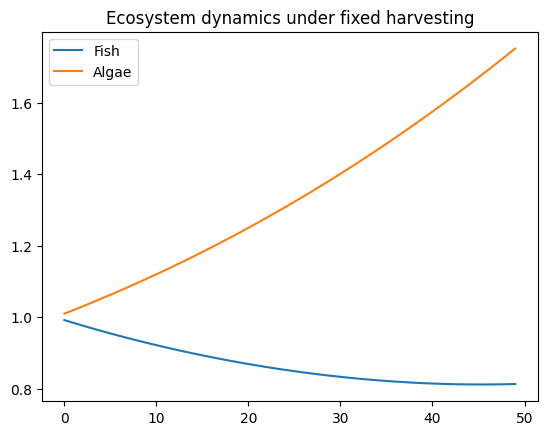

In [26]:
import matplotlib.pyplot as plt

# Create mechanism and space
m = FisheryMechanismSpace.default()

# Minimal fake world + env setup (for illustration)
env = FisheryRegulatedEnv(
    world=None,              # mock usage
    opt_id=None,
    agents=["f0", "f1", "f2"],
    mechanism_space=FisheryMechanismSpace,
    ecology_cfg={
        "fish_init": 1.0,
        "algae_init": 1.0,
        "max_fish": 2.0,
        "max_algae": 2.0,
        "alpha": 1.0,
        "beta": 0.5,
        "gamma": 0.4,
        "delta": 0.6,
        "dt": 0.02,
    },
    horizon=50,
)

# Manually inject mechanism (bypassing Ray world actor)
env.m = m
env.m_ctx = None  # Not needed for basic testing
env._t = 0
env.rng = np.random.default_rng(42)

# Manually call domain-specific reset (skip _pre_reset which needs world)
env.S_t = {
    "fish": env.fish_init,
    "algae": env.algae_init,
}

fish, algae = [], []

for _ in range(50):
    actions = {a: np.array([0.2], dtype=np.float32) for a in env.agents}
    
    # Manually step dynamics (bypass full step() which may need world)
    env.S_t = env.transition_kernel(actions, env.S_t)
    fish.append(env.S_t["fish"])
    algae.append(env.S_t["algae"])

plt.plot(fish, label="Fish")
plt.plot(algae, label="Algae")
plt.legend()
plt.title("Ecosystem dynamics under fixed harvesting")
plt.show()

### Outer Loop: Policy Evaluation

The institution does **not** observe gradients.

It receives:
- Episode-level statistics
- Sustainability metrics
- Aggregate performance

And computes:

$$
J_{\text{outer}}(\mu) =
\bar{R}(\mu) - \lambda \bar{P}(\mu)
$$


### Fitness as a First-Class Object

We encapsulate institutional feedback as a **FitnessContext**:

- Objective score
- Mean reward
- Collapse rate
- Sustainability penalty

This is the *only signal* the outer optimizer sees.


In [ ]:
from core.world.context import ContextSchema


class FitnessContext(ContextSchema):
    """
    Fitness signal emitted by the inner loop after evaluation.

    Conceptual role:
        This is the *only* information channel from the inner problem
        (agents learning under a mechanism) to the outer problem
        (institution optimizing mechanisms).

    Published by:
        - Inner optimizer / evaluator (e.g., PPO evaluation pass)

    Consumed by:
        - RegulatorEnv.aggregate_rewards (outer-loop ES fitness computation)

    Why this exists:
        - Decouples outer optimization from RLlib internals
        - Makes evaluation outputs explicit, typed, and loggable
        - Enables swapping evaluation logic without changing ES
    """

    objective_score: float
    mean_reward: float
    collapse_rate: float
    sustainability_penalty: float

    @classmethod
    def from_metrics(
        cls,
        *,
        mean_reward: SupportsFloat,
        collapse_rate: SupportsFloat,
        sustainability_penalty: SupportsFloat,
        sustainability_weight: SupportsFloat,
    ) -> "FitnessContext":
        """
        Construct a FitnessContext from evaluation metrics.

        Contract:
            Inputs may be numpy scalars or Python floats.
            Output is a fully-typed, JSON/log-friendly object.

        Objective definition (fishery):
            J_outer = mean_reward - λ * sustainability_penalty

        Why this method matters:
            - Centralizes the institutional objective definition
            - Prevents duplicated objective logic across evaluators
        """
        objective = float(mean_reward - sustainability_weight * sustainability_penalty)

        return cls(
            objective_score=objective,
            mean_reward=float(mean_reward),
            collapse_rate=float(collapse_rate),
            sustainability_penalty=float(sustainability_penalty),
        )

In [ ]:
fc = FitnessContext.from_metrics(
    mean_reward=8.2,
    collapse_rate=0.15,
    sustainability_penalty=0.4,
    sustainability_weight=5.0,
)

print("Institutional objective:", fc.objective_score)
print("Mean reward:", fc.mean_reward)
print("Collapse rate:", fc.collapse_rate)


In [ ]:
from contextvars import Context
from core.envs.regulator import RegulatorEnv
from core.world.context import EnvStepContext, MechanismContext, MechanismStatus

class FisheryRegulatorEnv(RegulatorEnv):
    """
    Outer-loop environment for institutional optimization.

    Conceptual role:
        - Orchestrates inner training
        - Aggregates outcomes across episodes
        - Produces scalar fitness for ES

    This environment never learns.
    """

    def __init__(self, *, ecology_cfg: dict, **kwargs):
        super().__init__(**kwargs)
        self.sustainability_weight = ecology_cfg.get("sus_weight", 5.0)
        self.sustainability_threshold = ecology_cfg.get("sus_threshold", 0.1)

    
    def observation(self, obs):
        """
        Observation for the outer optimizer.

        Design choice:
            Outer-loop optimization is treated as
            a stateless bandit problem.
        """
        return 0.0
    
    def aggregate_rewards(self, ctxs: list[Context]) -> list[float]:
        """
        Aggregate step-level contexts into per-mechanism fitness.

        Conceptual role:
            Implements J_outer(μ).

        Responsibilities:
            - Group rollouts by mechanism
            - Compute sustainability statistics
            - Publish FitnessContext objects
        """
        step_ctxs = [
            ctx for ctx in ctxs if isinstance(ctx.payload, EnvStepContext)
        ]

        if not step_ctxs:
            return []

        # group by mechanism index
        by_idx = {}
        for ctx in step_ctxs:
            by_idx.setdefault(ctx.payload.mechanism, []).append(ctx)

        min_len = min(len(v) for v in by_idx.values())
        fitness = np.full(max(by_idx) + 1, -np.inf, dtype=np.float32)

        for idx, steps in by_idx.items():
            steps = steps[:min_len]

            rewards = np.array([
                sum(s.payload.reward.values())
                for s in steps
            ])

            fish = np.array([
                min(o[0] for o in s.payload.observation.values())
                for s in steps
            ])

            collapse = fish < self.sustainability_threshold

            # minimize collapse 
            penalty = np.maximum(
                0.0,
                (self.sustainability_threshold - fish)
                / max(1e-6, self.sustainability_threshold),
            )

            fitness_ctx = FitnessContext.from_metrics(
                mean_reward=float(rewards.mean()),
                collapse_rate=float(collapse.mean()),
                sustainability_penalty=float(penalty.mean()),
                sustainability_weight=self.sustainability_weight,
            )

            # TODO function to create mechanism context from mechanism - easier for end-use
            # TODO 
            self._publish(
                MechanismContext(
                    index=idx,
                    env_id=self.env_id,
                    status=MechanismStatus.done,
                    job=None,
                    mechanism=None,
                    metrics=fitness_ctx,
                )
            )

            fitness[idx] = fitness_ctx.objective_score

        return fitness.tolist()

In [ ]:
# hyperparam = 0 --> fully market doesnt care about nature
# h1--> 1 - rate is maximized


### Full Control Loop Summary

1. Sample mechanisms $ \mu_k $
2. Train agents under each $ \mu_k $
3. Evaluate sustainability + reward
4. Publish FitnessContext
5. Update ES distribution
6. Repeat


## The Config Builder: How the System Is Assembled

The `BilevelConfig` builder is a **declarative specification** of a bilevel optimization system.

Rather than manually wiring environments, optimizers, Ray settings, and policies,
the config builder lets you **describe the system at a high level**, and then
compile it into a runnable optimizer.

At a glance, the config defines:

- **What is being optimized** (the mechanism)
- **Who is learning** (agents vs institution)
- **How learning happens** (PPO, ES, etc.)
- **How resources are managed** (Ray)
- **How results are evaluated** (fitness contexts)

Conceptually:

BilevelConfig
├── world → shared context + event bus
├── mechanism → institutional policy space
├── ray → execution + resources
├── outer → policy search optimizer (ES, CMA-ES, Random, …)
└── inner → agent learning optimizer (PPO, SAC, …)

### `world(...)`: Shared Execution Context

The `world` defines the **shared runtime substrate** for all optimizers.

### Purpose
- Stores all emitted contexts (steps, metrics, mechanisms)
- Enables decoupled communication between inner and outer loops
- Acts as an event bus and logging backbone

### Key Parameters

- `world_name`
  - A human-readable identifier for the experiment
  - Used for logging, debugging, and multi-run isolation


### `mechanism(...)`: Institutional Policy Specification

The `mechanism` block defines **what the institution is allowed to decide**.

### Purpose
- Declares the policy object optimized by the outer loop
- Defines how policies are encoded/decoded
- Provides a default (baseline) institutional policy

### Parameters

- `space`
  - A `MechanismSpace` subclass
  - Defines the geometry of policy optimization
  - Maps optimizer vectors → semantic policies

- `default`
  - A concrete `Mechanism` instance
  - Used for:
    - initialization
    - sanity checks
    - baseline comparisons


### `ray(...)`: Execution & Resource Management

The `ray` block defines **how computation is executed**, not what is computed.

### Purpose
- Controls CPU/GPU allocation
- Ensures reproducibility
- Isolates runtime environments

### Common Parameters

- `device`
  - `"cpu"` or `"gpu"`
  - Controls visible hardware for Ray workers

- `num_cpus`
  - Total CPUs available to Ray
  - Shared across all optimizers

- `omp_threads`
  - Limits OpenMP threads (important for numerical stability)

- `logging_level`
  - Ray internal logging verbosity

- `runtime_env`
  - Files or directories to exclude from Ray workers
  - Critical for large repos and cluster runs


### `outer(...)`: Institutional Policy Optimizer (ES)

The outer optimizer searches over **mechanisms**, not actions.

In the fishery example, this optimizer decides:
- quotas
- fines
- bans
- sustainability thresholds

### Optimizer Type
`ESConfig` (Evolution Strategies)

### Training Parameters

- `sigma`
  - Initial exploration variance
  - Controls how aggressively policies are perturbed

- `mean_lr`
  - Learning rate for the distribution mean
  - Higher → faster but less stable convergence

- `sigma_lr`
  - Learning rate for variance adaptation

- `min_sigma`
  - Prevents premature convergence

- `max_sigma`
  - Prevents excessive exploration

### Environment Parameters

- `env`
  - The `RegulatorEnv` subclass
  - Orchestrates inner-loop training and evaluation

- `env_config`
  - Domain-specific institutional parameters
  - Example:
    - sustainability weights
    - collapse thresholds

- `horizon`
  - Evaluation horizon for each policy

- `train_iters`
  - How many inner-loop training cycles per policy

The outer optimizer:
- never steps the environment directly
- never sees agent observations
- only consumes **FitnessContext**


### `inner(...)`: Agent Learning Optimizer (PPO)

The inner optimizer learns **agent behavior under a fixed mechanism**.

### Optimizer Type
`PPOptimizerConfig` (PPO via RLlib)

### Resource Parameters

- `num_cpus_for_main_process`
  - CPU allocation for the learner process

### Framework Parameters

- `framework`
  - `"torch"` or `"tf"`

- `api_stack`
  - Toggles RLlib’s new/old APIs
  - Useful for stability vs features

### Environment Parameters

- `env`
  - `FisheryRegulatedEnv` (or any regulated environment)

- `env_config`
  - Domain dynamics (ecology parameters)
  - Initial state distributions
  - Random seeds

- `horizon`
  - Episode length
  - **Must match outer horizon**

### Environment Runner Parameters

- `num_env_runners`
  - Parallel environment workers

- `num_envs_per_env_runner`
  - Vectorized environments per worker
  - Often equals ES population size
  - **IMP** this defines the amount of mechanism parameters trained in a single inner loop batch

- `rollout_fragment_length`
  - Length of rollout chunks
  - Must align with horizon

- `batch_mode`
  - `"complete_episodes"` for clean evaluation

### Training Parameters

- `gamma`
  - Discount factor

- `lr`
  - Policy learning rate

- `train_batch_size`
  - Total samples per update

- `minibatch_size`
  - PPO minibatch size

### Evaluation Parameters

- `evaluation_interval`
  - When evaluation happens
  - `None` = manual control via outer loop

- `evaluation_duration`
  - Total timesteps for evaluation

- `evaluation_config`
  - Greedy actions
  - Fixed seeds
  - Deterministic rollouts

### Agents Specification

- `count`
  - Number of agents

- `policy`
  - Policy ID

- `observation_space`
  - Includes:
    - environment state
    - mechanism vector (conditioning)

- `action_space`
  - Agent control space


### Swapping Optimizers: Policy Design

Any optimizer can replace `ESConfig` or `PPOptimizerConfig` **without changing environments**,
as long as it subclasses `Optimizer`.

Examples:
- Replace ES with CMA-ES
- Replace PPO with SAC
- Replace PPO with analytic solvers
- Replace outer loop with grid search or Bayesian optimization
